---
title: "Depth, residual coupling & stability"
short_title: "07 · Depth & stability"
subtitle: "Stacking coupling layers deep buys expressiveness; keeping deep stacks trainable; and residual coupling as a preview of implicit flows"
description: >
  A coupling layer is half a transform, so expressiveness comes from depth — stacked
  blocks with alternating masks. This notebook shows depth improves the fit,
  examines what keeps a deep stack trainable (gradient clipping, ActNorm
  pre-conditioning, the RBIG warm-start), and previews residual coupling — the
  x + g(x) form whose invertibility needs a Lipschitz bound and whose inverse is a
  fixed-point iteration, bridging to the implicit flows of Part 9.
---

(sec-nb-cpl-07)=
# 07 — Depth, residual coupling & stability

We have the pieces of a coupling layer — the pattern, the bijector, the
conditioner, the mask. A single layer transforms only half the coordinates, so a
coupling *flow*'s power comes from **stacking**: $T = T_L \circ \cdots \circ T_1$
with alternating masks ([notebook 03](03_mask_design.ipynb)), each block adding
expressiveness. This notebook looks at the depth dimension — how much it buys, what
keeps deep stacks trainable, and the **residual** coupling variant that points
ahead to Part 9.

**What you will see**

- **Depth → expressiveness**: stacking coupling blocks steadily improves the fit.
- **Stability**: gradient clipping keeps a deep stack training well; a note on
  ActNorm pre-conditioning and the warm-start.
- **Residual coupling** ($T(x) = x + g(x)$): why invertibility needs $\mathrm{Lip}(g)<1$
  and the inverse is a Banach fixed-point iteration — a preview of implicit flows.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Flip, Invert
from flowjax.distributions import Normal, Transformed

import gauss_flows as gf
from gauss_flows._src.transforms.bijections.linear.rotation import HouseholderRotation
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)

rng = np.random.default_rng(0)
n = 3000
t = rng.uniform(0.5, 3.5, n)
arm = (rng.integers(0, 2, n) * 2 - 1)[:, None]
xy = arm * np.stack([t * np.cos(2.5 * t), t * np.sin(2.5 * t)], axis=1) + 0.08 * rng.standard_normal((n, 2))
X = jnp.asarray((xy - xy.mean(0)) / xy.std(0))


def build(key, depth, *, coupling="spline", actnorm=False):
    bijections = []
    for k in jr.split(key, depth):
        rk, c1, c2 = jr.split(k, 3)
        rot = HouseholderRotation(n_reflections=2, shape=(2,))
        rot = eqx.tree_at(lambda r: r.params, rot, jr.normal(rk, rot.params.shape))
        if coupling == "spline":
            mk = lambda kk: gf.RQSplineCoupling(kk, shape=(2,), n_bins=8, interval=4.0, nn_width=24, nn_depth=2)
        else:
            mk = lambda kk: gf.AffineCoupling(kk, shape=(2,), nn_width=24, nn_depth=2)
        block = [rot, mk(c1), Flip(shape=(2,)), mk(c2), Flip(shape=(2,))]
        if actnorm:
            block = [gf.ActNorm1D(shape=(2,))] + block
        bijections += block
    return Transformed(Normal(jnp.zeros(2)), Invert(Chain(bijections)))


def train(flow, *, steps=1200, peak_lr=3e-3, clip=1.0, batch=512, seed=1):
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    schedule = optax.cosine_onecycle_schedule(steps, peak_lr)
    opt = (optax.adam(schedule) if clip is None
           else optax.chain(optax.clip_by_global_norm(clip), optax.adam(schedule)))
    state = opt.init(params)

    @eqx.filter_jit
    def step(params, state, xb):
        loss, g = eqx.filter_value_and_grad(
            lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(xb)))(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    key = jr.key(seed)
    for _ in range(steps):
        key, sk = jr.split(key)
        params, state, _ = step(params, state, X[jr.randint(sk, (batch,), 0, X.shape[0])])
    return eqx.combine(params, static)


logp = lambda f: float(jax.vmap(f.log_prob)(X).mean())

## 1. Depth buys expressiveness

Each coupling block, between alternating masks, composes with the others into a
more expressive map. We fit RQ-spline coupling flows of increasing depth on the
spiral.

  depth 1: log p -1.719
  depth 2: log p -1.495
  depth 4: log p -1.434
  depth 8: log p -1.375


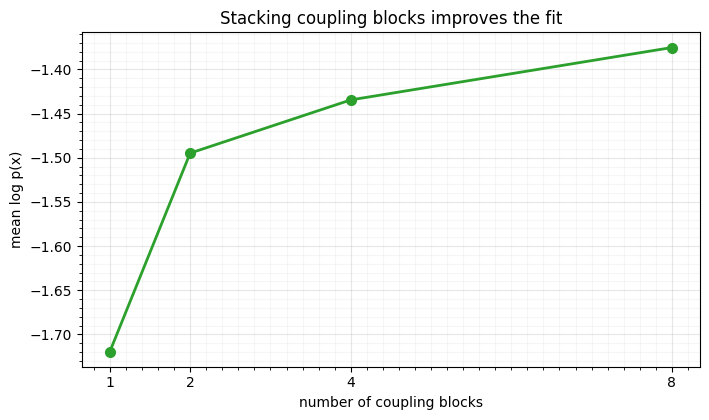

In [2]:
depths = [1, 2, 4, 8]
depth_lp = [logp(train(build(jr.key(0), d))) for d in depths]
for d, lp in zip(depths, depth_lp):
    print(f"  depth {d}: log p {lp:.3f}")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(depths, depth_lp, "o-", color="tab:green", lw=2, ms=7)
ax.set(title="Stacking coupling blocks improves the fit",
       xlabel="number of coupling blocks", ylabel="mean log p(x)", xticks=depths)
style_ax(ax)
fig.tight_layout()

Likelihood climbs steadily with depth — one spline coupling can only do so much,
but a stack composes them into the curved, non-separable map the spiral needs. The
gains taper as the flow saturates the target. (This is the coupling analogue of
RBIG's depth, Part 3 — but here every block is trained jointly.)

## 2. Keeping a deep stack trainable

Depth has a cost: gradients flow through every block, and a long composition can
amplify the occasional large update into a divergence. Well-conditioned stacks (the
RQ-spline flows above, even at depth 20) train fine at a moderate learning rate, but
push the rate up — or go deeper, or higher-dimensional — and stability tools earn
their keep. The most reliable in our loop is **gradient clipping**
(`optax.clip_by_global_norm`): it lets a deep **affine** stack (affine couplings are
less self-stabilising than splines) survive an aggressive learning rate.

  affine  gradient norm at depths [2, 4, 8, 16]: 1.8, 3.6, 2.4, 8.9
  spline  gradient norm at depths [2, 4, 8, 16]: 3.1, 5.3, 7.7, 37.1


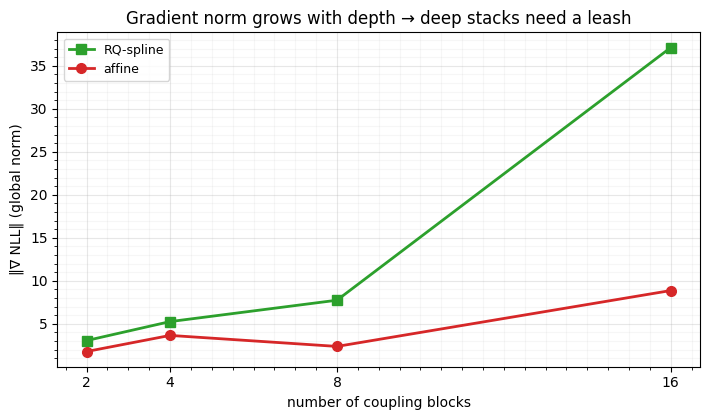

In [3]:
# Gradient norm of the NLL w.r.t. all parameters, for *untrained* stacks of growing
# depth — a training-free probe of how the composition amplifies gradients.
def grad_global_norm(flow):
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    grads = eqx.filter_grad(
        lambda p: -jnp.mean(jax.vmap(eqx.combine(p, static).log_prob)(X[:1000])))(params)
    return float(optax.global_norm(grads))

stack_depths = [2, 4, 8, 16]
gn = {c: [grad_global_norm(build(jr.key(0), d, coupling=c)) for d in stack_depths]
      for c in ["affine", "spline"]}
for c in gn:
    print(f"  {c:7s} gradient norm at depths {stack_depths}: "
          + ", ".join(f"{x:.1f}" for x in gn[c]))

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(stack_depths, gn["spline"], "s-", color="tab:green", lw=2, ms=7, label="RQ-spline")
ax.plot(stack_depths, gn["affine"], "o-", color="tab:red", lw=2, ms=7, label="affine")
ax.set(title="Gradient norm grows with depth → deep stacks need a leash",
       xlabel="number of coupling blocks", ylabel="‖∇ NLL‖ (global norm)", xticks=stack_depths)
ax.legend(fontsize=9); style_ax(ax)
fig.tight_layout()

The gradient norm **grows with depth** — composing more blocks amplifies the
back-propagated gradient (an order of magnitude over $2\to16$ blocks for the
spline). With a fixed learning rate that means deeper stacks take ever-larger
effective steps, so the occasional batch can blow training up. The standard
guards:

- **Gradient clipping** (`optax.clip_by_global_norm`, used throughout this part)
  caps that norm so depth cannot turn one bad batch into a NaN — cheap insurance
  that lets you train deep at an aggressive learning rate. (On the well-conditioned
  spline stacks of §1 a moderate rate already trains stably; the clip matters as you
  push rate, depth, or dimension.)
- **ActNorm pre-conditioning** (Part 2 [03](../02_rotations/03_conv1x1_actnorm.ipynb))
  — a per-channel affine that normalises activations between blocks, the Glow
  stabiliser {cite}`kingma2018glow`. It helps only when **data-dependently
  initialised** (loc/scale from the first batch); dropped in with default scale it
  compounds across depth and *hurts*, so it is a deliberate tool, not a free add-on.
- **RBIG warm-start** ([notebook 05](05_coupling_warmstart.ipynb)) — starting at the
  diagonal RBIG solution sidesteps the worst of the from-scratch transient.

Together — alternating masks, clipping, ActNorm (data-initialised), and a warm
start — these make very deep coupling flows trainable.

## 3. Residual coupling — a preview of implicit flows

Coupling gets its free log-det from a **triangular** Jacobian. A different family
trades that for a **residual** map,

$$
T(x) = x + g_\theta(x),
$$

where $g_\theta$ is an *unrestricted* network (no split, no mask). This is more
expressive per layer, but it is invertible only if $g_\theta$ is a contraction —
$\mathrm{Lip}(g_\theta) < 1$ — and then it has **no closed-form inverse**: you
recover $x$ from $y$ by Banach fixed-point iteration $x_{k+1} = y - g_\theta(x_k)$.
We illustrate the Lipschitz condition on a 1-D residual map $g(x)=a\sin(bx)$.

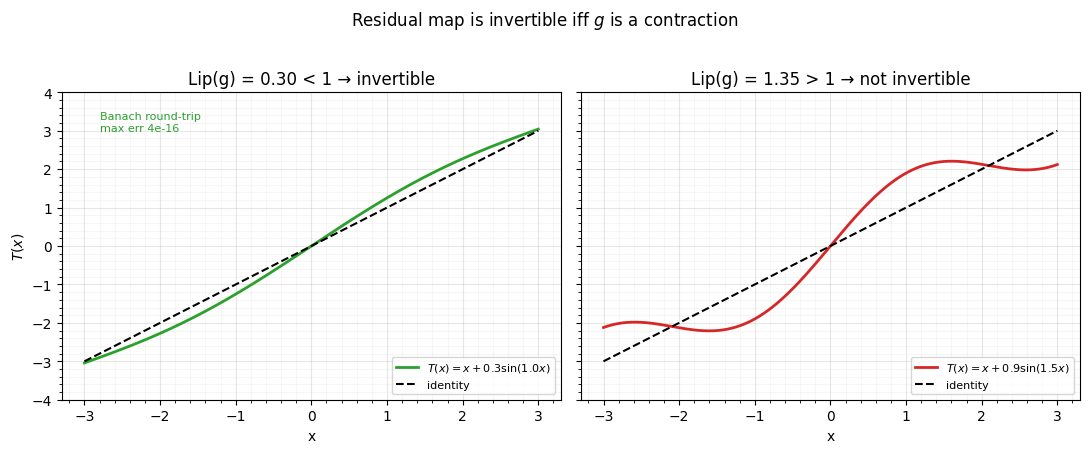

In [4]:
xx = np.linspace(-3, 3, 400)

def banach_inverse(y, a, b, iters=60):
    x = np.array(y, dtype=float)
    for _ in range(iters):
        x = y - a * np.sin(b * x)
    return x

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for ax, (a, b) in zip(axes, [(0.3, 1.0), (0.9, 1.5)]):
    y = xx + a * np.sin(b * xx)
    lip = a * b
    mono = bool(np.all(np.diff(y) > 0))
    ax.plot(xx, y, color="tab:green" if mono else "tab:red", lw=2,
            label=f"$T(x)=x+{a}\\sin({b}x)$")
    ax.plot([-3, 3], [-3, 3], **GAUSS_KW, label="identity")
    if mono:
        rt = np.abs(xx - banach_inverse(y, a, b)).max()
        ax.text(-2.8, 3.0, f"Banach round-trip\nmax err {rt:.0e}", fontsize=8, color="tab:green")
    ax.set(title=f"Lip(g) = {lip:.2f} {'< 1 → invertible' if lip < 1 else '> 1 → not invertible'}",
           xlabel="x", ylim=(-4, 4))
    ax.legend(fontsize=8, loc="lower right"); style_ax(ax)
axes[0].set_ylabel("$T(x)$")
fig.suptitle("Residual map is invertible iff $g$ is a contraction", y=1.02)
fig.tight_layout()

With $\mathrm{Lip}(g) = 0.3 < 1$ the map is monotone (invertible) and the
fixed-point iteration recovers $x$ to machine precision; with $\mathrm{Lip} = 1.35
> 1$ the map folds over and is no longer a bijection. Residual flows (Behrmann
2019) enforce the Lipschitz bound (spectral normalisation) and estimate the log-det
with a Hutchinson power series — trading coupling's free, exact machinery for more
expressiveness per layer and an iterative inverse. That trade is the subject of
**Part 9** (relaxed-bijectivity and implicit flows).

## Recap

| knob | effect |
|---|---|
| **depth** (stacked blocks) | composes expressiveness; gains taper at saturation |
| **gradient clipping** | the reliable deep-stack stabiliser in our loop |
| **ActNorm** (data-init) / **warm-start** | further conditioning for deep flows |
| **residual coupling** $x+g(x)$ | more expressive, but needs $\mathrm{Lip}(g)<1$ and an iterative inverse |

Coupling flows scale by depth, and the coupling contract (triangular Jacobian, free
log-det, exact inverse) survives every layer; residual flows give that contract up
for raw expressiveness — a deliberate trade revisited in Part 9.

**Part 5 → Part 6.** That completes **coupling-based Gaussianization**: the pattern
(00), bijector menu (01), conditioners (02), masks (03), the diagonal comparison
and warm-start (04–05), the equivalence (06), and depth/stability here. **Part 6 —
Continuous-time Gaussianization** takes the infinite-depth limit: instead of
stacking discrete blocks, a flow ODE $\dot x = v_\theta(x,t)$ transports the data to
$\mathcal{N}(0,I)$ continuously.